# VRPTW Batch Demo (Notebook)

This notebook is a small analysis-pipeline demo to:
- run Tabu on multiple instances in one go
- collect results in memory
- save a CSV snapshot
- generate quick comparison plots

You can start with small iterations for speed, then scale up for full experiments.

In [9]:
from pathlib import Path
import sys
import csv
import math
from datetime import datetime

import matplotlib.pyplot as plt

def find_src_root() -> Path:
    cwd = Path.cwd()
    candidates = [cwd] + list(cwd.parents)

    # Case 1: running from src or inside src/*
    for p in candidates:
        if (p / 'heuristics').exists() and (p / 'main.py').exists():
            return p

    # Case 2: running from repository root
    for p in candidates:
        src = p / 'src'
        if (src / 'heuristics').exists() and (src / 'main.py').exists():
            return src

    raise RuntimeError('Could not locate src root containing main.py and heuristics/.')

SRC_ROOT = find_src_root()
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

print(f'Using SRC_ROOT: {SRC_ROOT}')

Using SRC_ROOT: c:\Users\Jed\Desktop\9raya\heuristiques\src


In [ ]:
import main as cfg
from heuristics.tabu_search import run_tabu_from_method

BASE_PARAMS = {
    'method': cfg.TABU_START_METHOD,
    'iterations': cfg.TABU_ITERATIONS,
    'tabu_tenure': cfg.TABU_TENURE,
    'enable_dynamic_tenure': cfg.TABU_ENABLE_DYNAMIC_TENURE,
    'max_tabu_list_size': cfg.TABU_LIST_MAX_SIZE,
    'aspiration': cfg.TABU_ASPIRATION,
    'diversification_interval': cfg.TABU_DIVERSIFICATION_INTERVAL,
    'intensification_interval': cfg.TABU_INTENSIFICATION_INTERVAL,
    'total_neighbors': cfg.TABU_TOTAL_NEIGHBORS,
    'operator_percentages': cfg.TABU_OPERATOR_PERCENTAGES,
    'enabled_operators': cfg.TABU_OPERATORS,
    'print_iterations': False,
    'enable_improvement_operator': cfg.ENABLE_IMPROVEMENT_OPERATOR,
    'improvement_interval': cfg.IMPROVEMENT_INTERVAL,
    'regret_k': cfg.IMPROVEMENT_REGRET_K,
}

BASE_PARAMS

{'method': 'solomon',
 'iterations': 500,
 'tabu_tenure': 20,
 'aspiration': True,
 'diversification_interval': 35,
 'intensification_interval': 15,
 'total_neighbors': 480,
 'operator_percentages': {'relocate': 25.0,
  'swap': 20.0,
  'two_opt_intra': 15.0,
  'two_opt_inter': 15.0,
  'or_opt': 15.0,
  'cross_exchange': 10.0},
 'enabled_operators': ['relocate',
  'swap',
  'two_opt_intra',
  'two_opt_inter',
  'or_opt',
  'cross_exchange'],
 'print_iterations': False,
 'enable_improvement_operator': True,
 'improvement_interval': 30,
 'regret_k': 2}

In [ ]:
# Experiment plan: each item can override any BASE_PARAMS field.
EXPERIMENTS = [
    {
        "name": "C201_fast_solomon",
        "instance": "C201",
        "overrides": {
            "method": "solomon",
            "iterations": 80,
            "total_neighbors": 320,
        },
    },
    {
        "name": "R201_medium_solomon",
        "instance": "R201",
        "overrides": {
            "method": "solomon",
            "iterations": 120,
            "total_neighbors": 480,
            "tabu_tenure": 24,
        },
    },
    {
        "name": "RC201_alt_mix",
        "instance": "RC201",
        "overrides": {
            "method": "solomon",
            "iterations": 100,
            "total_neighbors": 420,
            "operator_percentages": {
                "relocate": 30.0,
                "swap": 15.0,
                "two_opt_intra": 15.0,
                "two_opt_inter": 15.0,
                "or_opt": 15.0,
                "cross_exchange": 10.0,
            },
        },
    },
]

# Optional common overrides applied to all experiments.
GLOBAL_OVERRIDES = {
    "print_iterations": False,
}

print(f"Planned runs: {len(EXPERIMENTS)}")
for exp in EXPERIMENTS:
    merged = dict(BASE_PARAMS)
    merged.update(GLOBAL_OVERRIDES)
    merged.update(exp.get("overrides", {}))
    print(
        f"- {exp['name']}: instance={exp['instance']}, "
        f"method={merged['method']}, "
        f"iterations={merged['iterations']}, "
        f"neighbors={merged['total_neighbors']}"
    )

Planned runs: 3
- C201_fast_solomon: instance=C201, method=solomon, iterations=80, neighbors=320
- R201_medium_solomon: instance=R201, method=solomon, iterations=120, neighbors=480
- RC201_alt_mix: instance=RC201, method=solomon, iterations=100, neighbors=420


In [ ]:
results = []

for exp in EXPERIMENTS:
    name = exp["name"]
    instance = exp["instance"]

    run_params = dict(BASE_PARAMS)
    run_params.update(GLOBAL_OVERRIDES)
    run_params.update(exp.get("overrides", {}))

    print(f"Running {name} ({instance}) ...")
    row = run_tabu_from_method(instance=instance, **run_params)

    init_d = row.get("init_distance", float("inf"))
    best_d = row.get("tabu_distance", float("inf"))
    if isinstance(init_d, (int, float)) and isinstance(best_d, (int, float)) and math.isfinite(init_d) and init_d > 0 and math.isfinite(best_d):
        row["savings_pct"] = (init_d - best_d) / init_d * 100.0
    else:
        row["savings_pct"] = 0.0

    # Keep experiment metadata for analysis and plotting.
    row["experiment"] = name
    row["config_method"] = run_params.get("method")
    row["config_iterations"] = run_params.get("iterations")
    row["config_total_neighbors"] = run_params.get("total_neighbors")
    row["config_enable_dynamic_tenure"] = run_params.get("enable_dynamic_tenure")
    row["config_max_tabu_list_size"] = run_params.get("max_tabu_list_size")

    results.append(row)

print(f"Finished {len(results)} runs.")

Running C201_fast_solomon (C201) ...
Running R201_medium_solomon (R201) ...
Running RC201_alt_mix (RC201) ...
Finished 3 runs.


In [13]:
print(f"{'Experiment':<24} {'Instance':<8} {'Init':>12} {'Best':>12} {'Save%':>8} {'Feas':>6} {'Routes':>8} {'Time(s)':>10}")
print('-' * 104)
for r in sorted(results, key=lambda x: x.get('experiment', x['instance'])):
    print(
        f"{r.get('experiment', '-'): <24} "
        f"{r['instance']:<8} "
        f"{r['init_distance']:>12.3f} "
        f"{r['tabu_distance']:>12.3f} "
        f"{r['savings_pct']:>8.2f} "
        f"{str(r['tabu_feasible']):>6} "
        f"{r['routes_used']:>8} "
        f"{r['total_elapsed_seconds']:>10.3f}"
    )

Experiment               Instance         Init         Best    Save%   Feas   Routes    Time(s)
--------------------------------------------------------------------------------------------------------
C201_fast_solomon        C201          594.323      591.557     0.47   True        3     72.084
R201_medium_solomon      R201         1850.896     1348.193    27.16   True        5     33.489
RC201_alt_mix            RC201        2245.050     1413.670    37.03   True        5     27.222


In [ ]:
results_dir = SRC_ROOT / "results"
results_dir.mkdir(parents=True, exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
csv_path = results_dir / f"notebook_batch_demo_{timestamp}.csv"

columns = [
    "experiment",
    "instance",
    "method",
    "config_method",
    "config_iterations",
    "config_total_neighbors",
    "config_enable_dynamic_tenure",
    "config_max_tabu_list_size",
    "init_distance",
    "tabu_distance",
    "savings_pct",
    "tabu_feasible",
    "routes_used",
    "vehicles_available",
    "total_elapsed_seconds",
    "message",
    "best_routes",
]

with csv_path.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=columns)
    writer.writeheader()
    for r in results:
        row = dict(r)
        row["best_routes"] = " || ".join("->".join(map(str, route)) for route in r.get("best_routes", []))
        writer.writerow({k: row.get(k) for k in columns})

print(f"Saved: {csv_path}")

Saved: c:\Users\Jed\Desktop\9raya\heuristiques\src\results\notebook_batch_demo_20260420_231417.csv


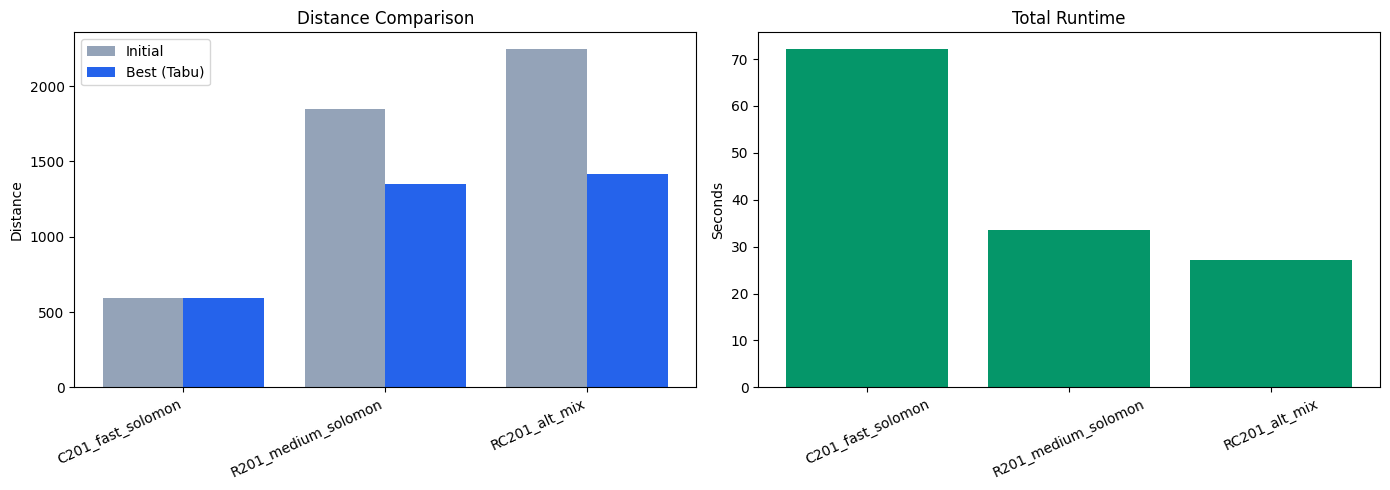

In [15]:
labels = [r.get("experiment", r["instance"]) for r in results]
init_dist = [r["init_distance"] for r in results]
best_dist = [r["tabu_distance"] for r in results]
elapsed = [r["total_elapsed_seconds"] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = range(len(labels))
axes[0].bar([i - 0.2 for i in x], init_dist, width=0.4, label="Initial", color="#94a3b8")
axes[0].bar([i + 0.2 for i in x], best_dist, width=0.4, label="Best (Tabu)", color="#2563eb")
axes[0].set_title("Distance Comparison")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(labels, rotation=25, ha="right")
axes[0].set_ylabel("Distance")
axes[0].legend()

axes[1].bar(labels, elapsed, color="#059669")
axes[1].set_title("Total Runtime")
axes[1].set_ylabel("Seconds")
axes[1].tick_params(axis="x", rotation=25)

fig.tight_layout()
plt.show()

In [16]:
# Optional: inspect one final solution in detail
focus_experiment = results[0]["experiment"] if results else ""
focus = next((r for r in results if r.get("experiment") == focus_experiment), None)

if focus is None:
    print("Experiment not found in results.")
else:
    print(f"Experiment: {focus.get('experiment', '-')}")
    print(f"Instance: {focus['instance']}")
    print(f"Best distance: {focus['tabu_distance']:.3f}")
    print(f"Routes used: {focus['routes_used']}")
    print("Best routes:")
    for idx, route in enumerate(focus.get("best_routes", []), start=1):
        print(f"  Route {idx}: {' -> '.join(str(node) for node in route)}")

Experiment: C201_fast_solomon
Instance: C201
Best distance: 591.557
Routes used: 3
Best routes:
  Route 1: 0 -> 93 -> 5 -> 75 -> 2 -> 1 -> 99 -> 100 -> 97 -> 92 -> 94 -> 95 -> 98 -> 7 -> 3 -> 4 -> 89 -> 91 -> 88 -> 84 -> 86 -> 83 -> 82 -> 85 -> 76 -> 71 -> 70 -> 73 -> 80 -> 79 -> 81 -> 78 -> 77 -> 96 -> 87 -> 90 -> 0
  Route 2: 0 -> 20 -> 22 -> 24 -> 27 -> 30 -> 29 -> 6 -> 32 -> 33 -> 31 -> 35 -> 37 -> 38 -> 39 -> 36 -> 34 -> 28 -> 26 -> 23 -> 18 -> 19 -> 16 -> 14 -> 12 -> 15 -> 17 -> 13 -> 25 -> 9 -> 11 -> 10 -> 8 -> 21 -> 0
  Route 3: 0 -> 67 -> 63 -> 62 -> 74 -> 72 -> 61 -> 64 -> 66 -> 69 -> 68 -> 65 -> 49 -> 55 -> 54 -> 53 -> 56 -> 58 -> 60 -> 59 -> 57 -> 40 -> 44 -> 46 -> 45 -> 51 -> 50 -> 52 -> 47 -> 43 -> 42 -> 41 -> 48 -> 0
